# Different Selection strategies (UCB, UCB-Tuned, RAVE, n-grams)

In [1]:
# import external libraries
from qiskit import qpy
import evaluation_functions as evf
import mcts_group_selection as mcts
from structure import Circuit
import itertools
import os
# import seaborn as sns
from tqdm import tqdm
import csv
# import functions, classes and objects

In [2]:
#reload kernal for changes in file
import importlib
importlib.reload(mcts)

<module 'mcts_group_selection' from '/Users/geordangesink/Documents/Uni/BTR/code/masterproj_MCTS_2024/mcts_group_selection.py'>

In [6]:
num_runs = 10
params = {
    'collect_data': [True],
    'evaluation_function': [evf.h2, evf.lih, evf.h2o, evf.vqls_0, evf.vqls_1],
    # 'choices': [{'a': 20, 'd': 20, 's': 20, 'c': 20, 'p': 20}],
    # 'stop_deterministic': [False],


 # TEST BEST ONES

# Change from here
    'group_by_gates': [False],
    'group_by_action': [True],
    'terminal_nodes': [False],
    'group_by_change': [False],
    'group_by_swap': [False],
    'finite_progressive_widening': [True],

    'selection_method': ['n-grams'],
    'n': [1],
}
# name = 'selection-UCB'
# name = 'selection-UCB_tuned'
# name = 'selection-RAVE'
name = 'selection-1_grams'

# selection_method = 'UCB'
# selection_method = 'UCB-tuned'
# selection_method = 'RAVE'
# selection_method = 'n-grams'

In [7]:
nqbits = {'h2': 4, 'lih': 10, 'h2o': 8,'vqls_1': 4,'vqls_0': 4}
budgets = {'h2': 5000, 'lih': 5000, 'h2o': 5000,'vqls_1': 5000,'vqls_0': 5000}
keys = list(params)
results_folder = 'results'

def test_all_vars_one_problem(max_depth, verbose=False):   
    count = 0 
    for values in tqdm(itertools.product(*map(params.get,keys))):
        count += 1
        print(values)
        for i in range(num_runs):
            evf = values[1]
            evf_name = evf.__name__
            print(evf_name, count)
            folder_name = f"{results_folder}/{name}/{evf_name}"
            os.makedirs(folder_name, exist_ok=True)  # Create the folder if it doesn't exist
            filename = f"{name}_{i}.csv"
            csv_path = os.path.join(folder_name, filename)
            if not os.path.isfile(csv_path):
                root = mcts.Node(Circuit(variable_qubits=nqbits[evf_name], ancilla_qubits=0), max_depth=max_depth)
                results = mcts.mcts(root, **dict(zip(keys,values)), budget=budgets[evf_name], verbose=verbose)
                objective_values = results['data'] 
                objective_values.to_csv(csv_path, index=False)

                qc_last = results['qc'][-1]
                qc_best = results['best_qc']
                data = [
                    ["Category", "EnergyBefore", "ValueBefore", "EnergyAfter", "ValueAfter", "H", "Cx", "Rx", "Ry", "Rz"]
                ]
                for id, circ in {"last": qc_last, "best": qc_best}.items():
                    arr = []
                    with open(f"{results_folder}/{name}/{evf_name}/{name}_{i}_{id}_circuit.qpy", "wb") as file:
                        qpy.dump(circ, file)
                    optim = [evf(quantum_circuit=circ)] if "vqls_0" in evf_name else evf(quantum_circuit=circ, gradient=True)
                    energy_before = optim[0]
                    value_before = -energy_before    
                    energy_after = optim[-1]
                    value_after = -energy_after    
                    gate_counts = dict(circ.count_ops())
                    h_gates = gate_counts["h"] if "h" in gate_counts.keys() else 0
                    cx_gates = gate_counts["rx"] if "rx" in gate_counts.keys() else 0
                    rx_gates = gate_counts["ry"] if "ry" in gate_counts.keys() else 0
                    ry_gates = gate_counts["rz"] if "rz" in gate_counts.keys() else 0
                    rz_gates = gate_counts["cx"] if "cx" in gate_counts.keys() else 0
                    arr = [id, energy_before, value_before, energy_after, value_after, h_gates, cx_gates, rx_gates, ry_gates, rz_gates]
                    data.append(arr)

                with open(f"{results_folder}/{name}/{evf_name}/{name}_{i}_optimized.csv", mode='w', newline='', encoding='utf-8') as file:
                    writer = csv.writer(file)
                    writer.writerows(data)
        
test_all_vars_one_problem(10, False)

0it [00:00, ?it/s]

(True, <function h2 at 0x1386d07c0>, False, True, False, False, False, True, 'n-grams', 1)
h2 1


/opt/homebrew/lib/python3.11/site-packages/autograd/tracer.py:14: UserWarning: Output seems independent of input.
  warnings.warn("Output seems independent of input.")


Step = 0,  Energy = -0.04207898 Ha
Landscape is flat
Step = 0,  Energy = -0.76925678 Ha
Step = 2,  Energy = -0.78855112 Ha
Step = 4,  Energy = -0.80762937 Ha
Step = 6,  Energy = -0.82644295 Ha
Step = 8,  Energy = -0.84496255 Ha
Step = 10,  Energy = -0.86316439 Ha
Step = 12,  Energy = -0.88100347 Ha
Step = 14,  Energy = -0.89841518 Ha
Step = 16,  Energy = -0.91533331 Ha
Step = 18,  Energy = -0.93170311 Ha
Step = 20,  Energy = -0.94748679 Ha
Step = 22,  Energy = -0.96265859 Ha
Step = 24,  Energy = -0.97719229 Ha
Step = 26,  Energy = -0.99105375 Ha
Step = 28,  Energy = -1.00420455 Ha
Step = 30,  Energy = -1.01660950 Ha
Step = 32,  Energy = -1.02824071 Ha
Step = 34,  Energy = -1.03907544 Ha
Step = 36,  Energy = -1.04909334 Ha
Step = 38,  Energy = -1.05827956 Ha
Step = 40,  Energy = -1.06663142 Ha
Step = 42,  Energy = -1.07416126 Ha
Step = 44,  Energy = -1.08089305 Ha
Step = 46,  Energy = -1.08685768 Ha
Step = 48,  Energy = -1.09209192 Ha
Step = 50,  Energy = -1.09663932 Ha
Step = 52,  Ener

/opt/homebrew/lib/python3.11/site-packages/autograd/tracer.py:14: UserWarning: Output seems independent of input.
  warnings.warn("Output seems independent of input.")


...

(True, <function vqls_1 at 0x17e8dc040>, False, True, False, False, False, True, 'n-grams', 1)
vqls_1 5

Final value of the cost function is  0.3852 
Landscape is flat

Final value of the cost function is  0.0135 
vqls_1 5

Final value of the cost function is  0.0136 
Landscape is flat

Final value of the cost function is  0.0135 
vqls_1 5

Final value of the cost function is  0.2273 
Landscape is flat

Final value of the cost function is  0.0135 
vqls_1 5

Final value of the cost function is  0.1540 
Landscape is flat

Final value of the cost function is  0.0135 
vqls_1 5

Final value of the cost function is  0.3246 
Landscape is flat

Final value of the cost function is  0.0135 
vqls_1 5


/opt/homebrew/lib/python3.11/site-packages/autograd/tracer.py:14: UserWarning: Output seems independent of input.
  warnings.warn("Output seems independent of input.")



Final value of the cost function is  0.1329 
Landscape is flat

Final value of the cost function is  0.0135 
vqls_1 5
Landscape is flat

Final value of the cost function is  0.4394 
Landscape is flat

Final value of the cost function is  0.0135 
vqls_1 5

Final value of the cost function is  0.1166 
Landscape is flat

Final value of the cost function is  0.0135 
vqls_1 5

Final value of the cost function is  0.2386 
Landscape is flat

Final value of the cost function is  0.0135 
vqls_1 5

Final value of the cost function is  0.2270 


5it [4:15:12, 3062.57s/it]

Landscape is flat

Final value of the cost function is  0.0135 


# Add to JSON

In [8]:
import analysing_utils

results = analysing_utils.load_circuit_results()

In [9]:
def copy_without_qc(data):
    """Recursively copy the dictionary while excluding keys named 'qc'."""
    if isinstance(data, dict):
        # Process each key-value pair in the dictionary
        return {key: copy_without_qc(value) for key, value in data.items() if key != "qc"}
    elif isinstance(data, list):
        # Process each element in the list
        return [copy_without_qc(item) for item in data]
    else:
        # Return the value directly if it's not a list or dictionary
        return data

In [10]:
import numpy as np

def convert_ndarray_to_list(data):
    if isinstance(data, dict):
        return {key: convert_ndarray_to_list(value) for key, value in data.items()}
    elif isinstance(data, list):
        return [convert_ndarray_to_list(item) for item in data]
    elif isinstance(data, np.ndarray):
        return data.tolist()
    else:
        return data

In [11]:
filtered_dict = convert_ndarray_to_list(copy_without_qc(results))

In [12]:
import json 

with open("results.json", "w") as outfile: 
    json.dump(filtered_dict, outfile)

# Plotting

In [13]:
import analysing_utils
import matplotlib.pyplot as plt

In [14]:
results = analysing_utils.load_mcts_results()
print(results)

{'h2o': {'selection-1_grams': [      budget expandedBy  objectiveValue   epoch  treeDepth  parentValue    H  \
0        0.0        NaN       74.555902     0.0        0.0     0.000000  8.0   
1        1.0        add       74.550028     1.0        1.0    74.555902  8.0   
2        2.0     delete       74.540769     1.0        1.0    74.555902  7.0   
3        3.0       swap       74.620274     1.0        1.0    74.555902  7.0   
4        4.0        add       74.549214     2.0        2.0    74.550028  8.0   
...      ...        ...             ...     ...        ...          ...  ...   
4996  4996.0        add       74.794363  3977.0      404.0    74.112067  0.0   
4997  4997.0     delete       74.751519  3978.0      406.0    74.748864  0.0   
4998  4998.0        add       74.704301  3978.0      406.0    74.748864  0.0   
4999  4999.0     delete       74.374056  3978.0      406.0    74.748864  0.0   
5000  5000.0       swap       74.857467  3978.0      406.0    74.748864  0.0   

       R

In [3]:
problems = ["h2", "h2o", "lih", "vqls_0", "vqls_1"]
optimal_value = {"h2": 1.117, "h2o": 75.4217, "lih": 7.973, "vqls_0": 0, "vqls_1": 0}

In [ ]:
variants = [ 'selection-UCB', 'selection-UCB_tuned', 'selection-RAVE', 'selection-n_grams' , 'selection-1_grams']

In [5]:
convergence = analysing_utils.converge_all(results, problems, variants)

In [ ]:
color_palette =  {
    "selection-UCB": 'red',
    "selection-UCB_tuned": 'green',
    "selection-RAVE": 'blue',
    'selection-n_grams': 'yellow',
    'selection-1_grams': 'black',
    "standard": "purple",
    "standard_nc": "lime",
    "standard_nc_prob": "blue",  # TODO: Make correct baseline blue
    "terminal_nc": "yellow",
    "terminal_nc_4": "magenta",

    "actions": "green",
    "actions_pw": "limegreen",

    "gates": "orange",
    "gates_pw": "bisque",

    "actions_gates": "darkslategrey",
    "actions_gates_pw": "teal",

    "actions_terminal": "orangered",
    "actions_pw_terminal": "lightsalmon",

    "gates_terminal": "deepskyblue",
    "gates_pw_terminal": "skyblue",

    "actions_gates_terminal": "darkslateblue",
    "actions_gates_pw_terminal": "mediumslateblue",

    "actions_change_gates_swap": "darkkhaki",
    "actions_change_gates_pw_swap": "palegoldenrod",

    "actions_change_gates_swap_terminal": "deeppink",
    "actions_change_gates_pw_swap_terminal": "hotpink",
}

baseline = None

#### Plot:

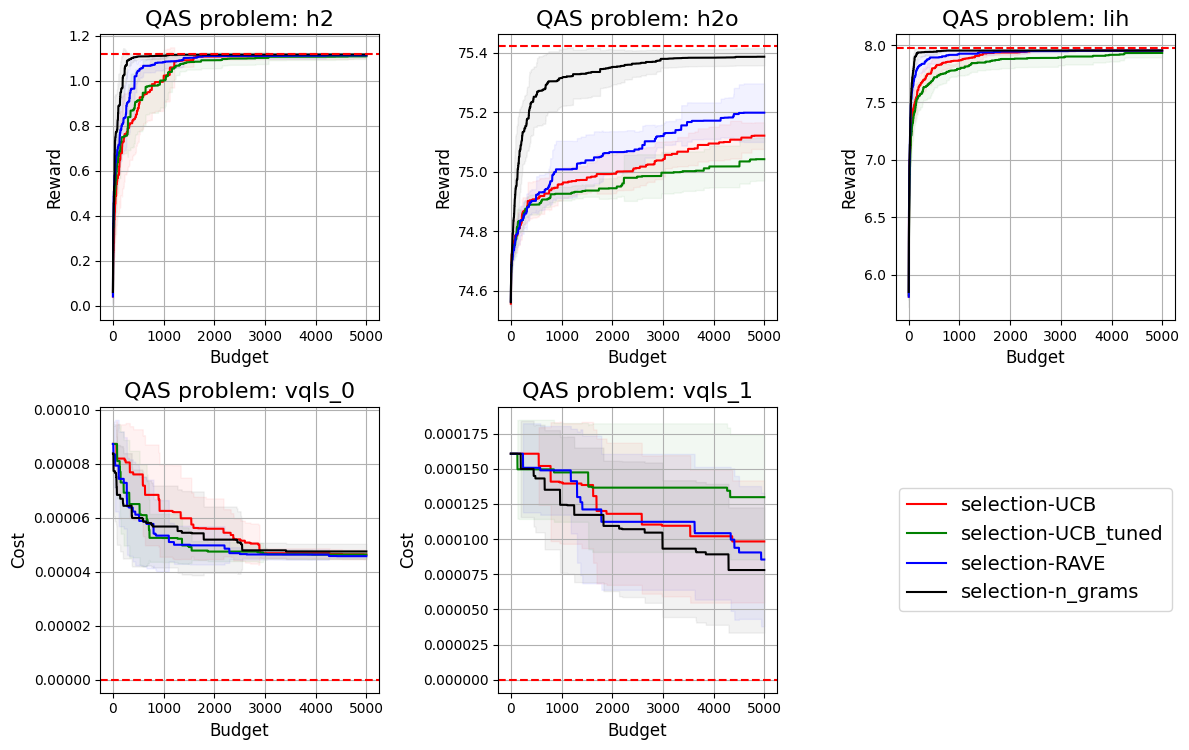

In [34]:
analysing_utils.plot_figure(problems, variants, optimal_value, convergence, color_palette, baseline)

#### Boxplot

In [35]:
import analysing_utils
import matplotlib.pyplot as plt
import pandas as pd

In [36]:
variants = [
    'selection-UCB'
#     # Standard
#     'standard',
#     'standard_nc',
#     'standard_nc_prob',
#     'terminal_nc',
#     'terminal',
#     # Actions
#     'actions',
#     'actions_gates',
#     'actions_gates_terminal',
#     'actions_terminal',
#     'actions_change_gates_swap',
#     'actions_change_gates_swap_terminal',
#     # Gates
#     'gates',
#     'gates_terminal',

# # Progresenive widening

#     # Actions
#     'actions_pw',
#     'actions_gates_pw',
#     'actions_gates_pw_terminal',
#     'actions_pw_terminal',
#     'actions_change_gates_pw_swap',
#     'actions_change_gates_pw_swap_terminal',
#     # Gates
#     'gates_pw',
#     'gates_pw_terminal',

    
]# 'action_change_gates_swap_terminal', 'terminal', 'gates_terminal', 'action_gates_terminal', 'action_terminal']
problems = ['h2', 'h2o', 'lih', 'vqls_0', 'vqls_1']
vql_problems = ['vqls_0', 'vqls_1']
chemistry_problems = ['h2', 'h2o', 'lih']
optimal_value = {'h2': 1.117, 'h2o': 75.42175236224648, 'lih': 7.95265005, 'vqls_0': 1, 'vqls_1': 1}

In [37]:
split_variants = []
for variant in variants:
    split_variants = split_variants + variant.split('_')
unique_vars = list(set(split_variants))
unique_vars

table_df = pd.DataFrame(columns=unique_vars)
table_df.head()

for variant in variants:
    variant.split('_')
    for col in unique_vars:
        table_df.at[variant, col] = 1 if col in variant.split('_') else 0

In [38]:
results = analysing_utils.load_mcts_results()

In [39]:
circuit_results = analysing_utils.load_circuit_results()

In [40]:
problem_stats = {}
for problem in problems:
    problem_results = []
    for variant in variants:
        problem_results.append(circuit_results[problem][variant])
    problem_stats[problem] =  analysing_utils.standardize_problem_stats(problem_results)

problem_stats
analysing_utils.standardize_from_stats(problem_stats["h2"], circuit_results["h2"]["gates"][0])

KeyError: 'gates'

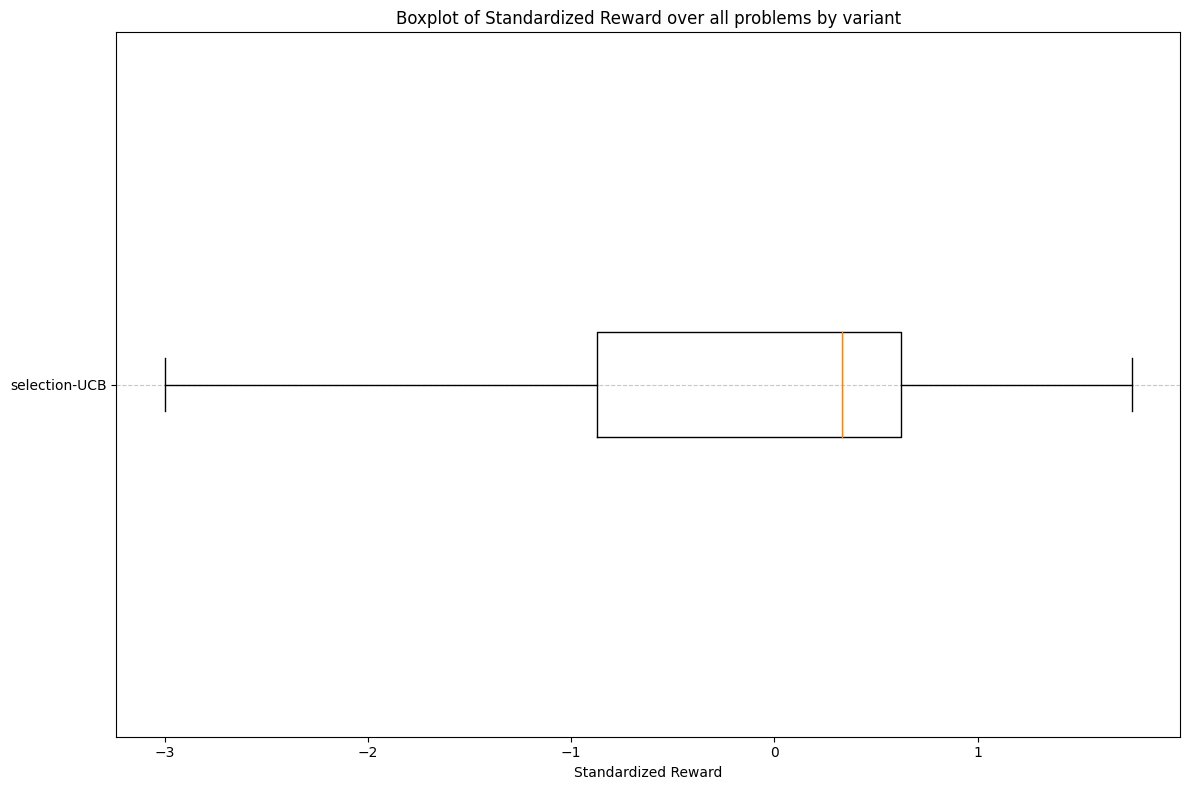

In [41]:
variant_results = {}
for variant in variants:
    standardized_results = []
    for problem in problems:
        for run in circuit_results[problem][variant]:
            result = analysing_utils.standardize_from_stats(problem_stats[problem], run)
            standardized_results.append(result)
    variant_results[variant] = standardized_results

variant_results
plt.figure(figsize=(12, 8))
plt.boxplot(variant_results.values(), labels=variant_results.keys(), vert=False)
plt.xlabel('Standardized Reward')
plt.title('Boxplot of Standardized Reward over all problems by variant')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add horizontal grid lines
plt.show()

ValueError: Dimensions of labels and X must be compatible

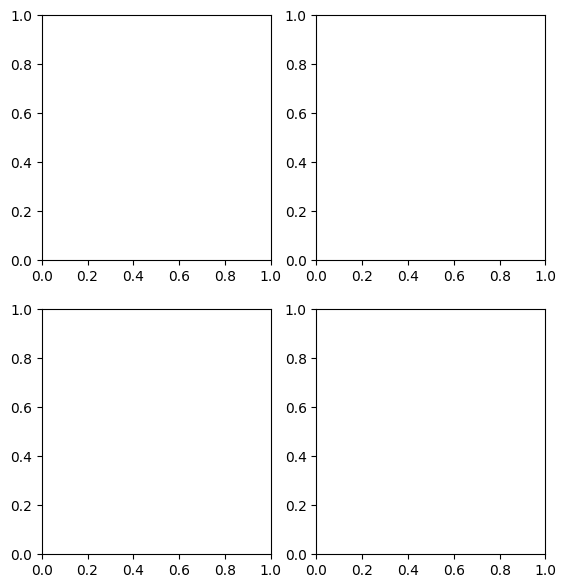

In [42]:
curate = ['standard_nc_prob','terminal_nc', 'gates', 'gates_terminal', 'actions', 'actions_change_gates_swap', 'actions_change_gates_swap_terminal','actions_pw_terminal']
circuit_results_curated = {problem: {key: circuit_results[problem][key] for key in curate if key in circuit_results[problem]} for problem in problems}

problems_curated = problems.copy()
problems_curated.remove('vqls_0')
problems_curated.remove('h2')
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(6.5, 7))
axes = axes.flatten()

for i, problem in enumerate(problems_curated):
    ax = axes[i]
    ax.boxplot(circuit_results_curated[problem].values(), labels=range(len(circuit_results_curated[problem].keys())))
    ax.axhline(y=optimal_value[problem], color='red', linestyle='--', alpha=0.2)
    ax.set_title(f"{problem}")
    if problem in ['h2o', 'lih']:
        ax.set_ylabel("reward (Ha)")
    else:
        ax.set_ylabel(r"reward ($e^{-10 \cdot cost}$)")
    ax.grid(axis='x', linestyle='--', alpha=0.7)  # Add horizontal grid lines

labels = ['Baseline', 'Baseline with Terminal', 'Group By Gates','Group By Gates with Terminal Nodes', 'Group By Actions', 'All Groupings', 'All Groupings with Terminal Nodes', 'Group by Actions with Progressive \nWidening and Terminal Nodes']
import matplotlib.lines as mlines

# Create dummy handles for the legend
handles = [mlines.Line2D([], [], color='black', marker=f'${i}$', linestyle='None') for i in range(8)]
fig.legend(handles, labels, loc='lower right', ncol=1, bbox_to_anchor=(1, 0.1), prop={'size': 8})  
axes[-1].axis('off')  # Hide the last subplot
plt.tight_layout()
plt.show()


['selection-UCB']


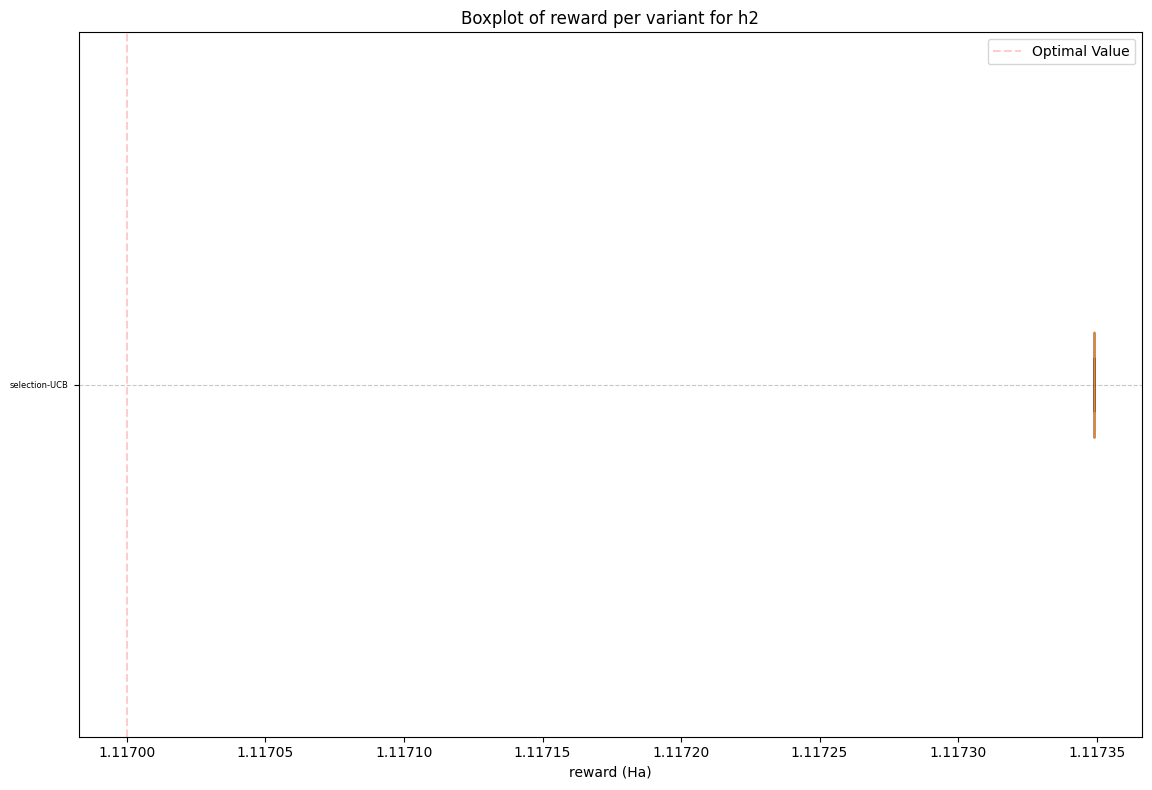

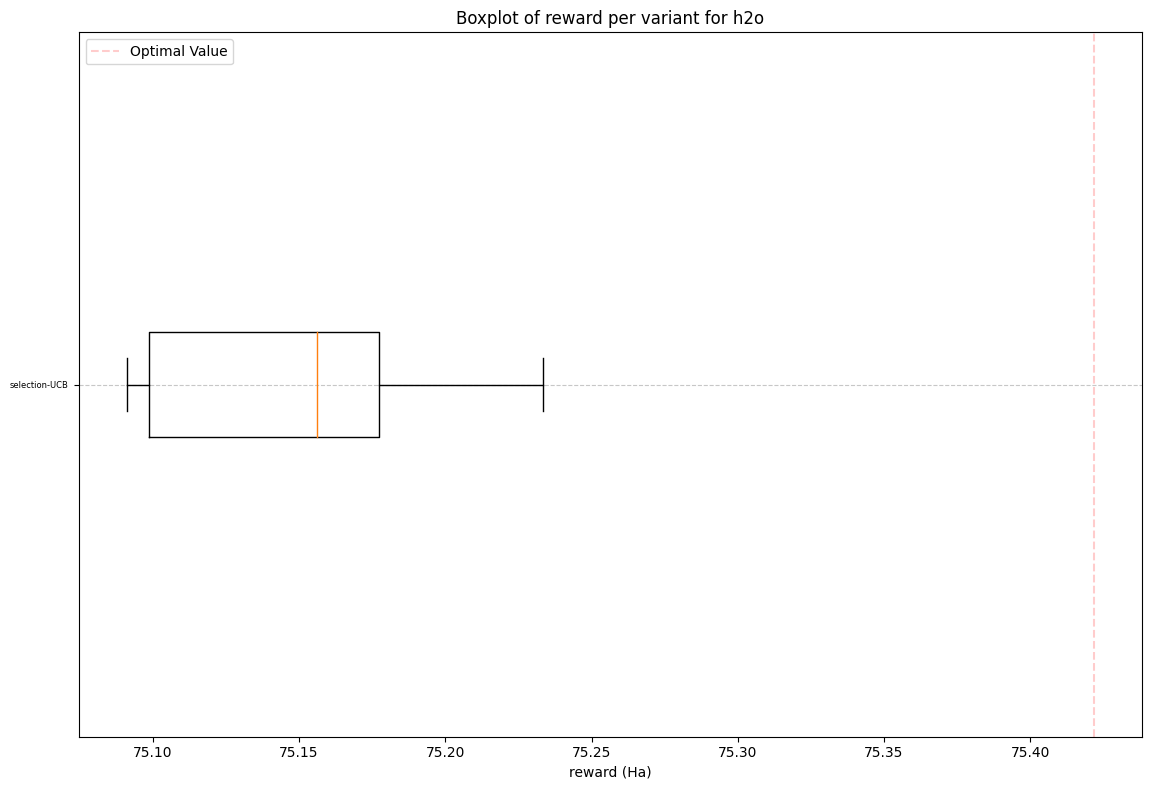

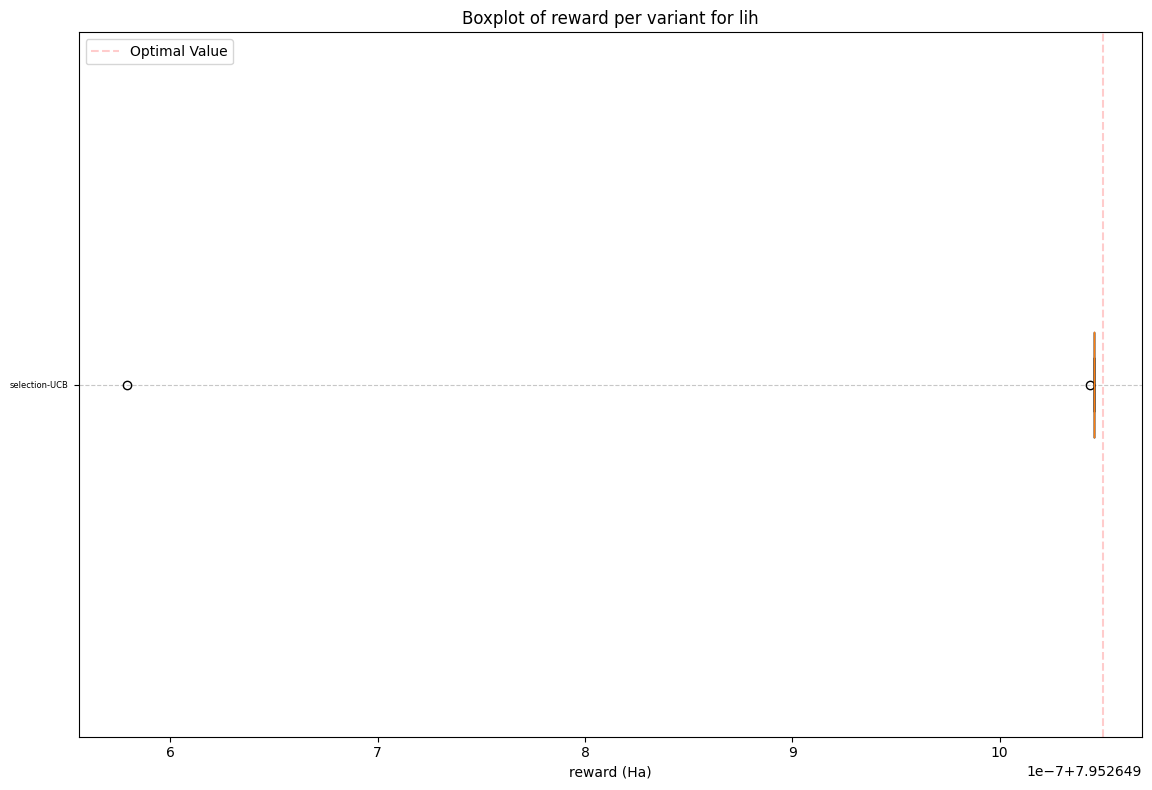

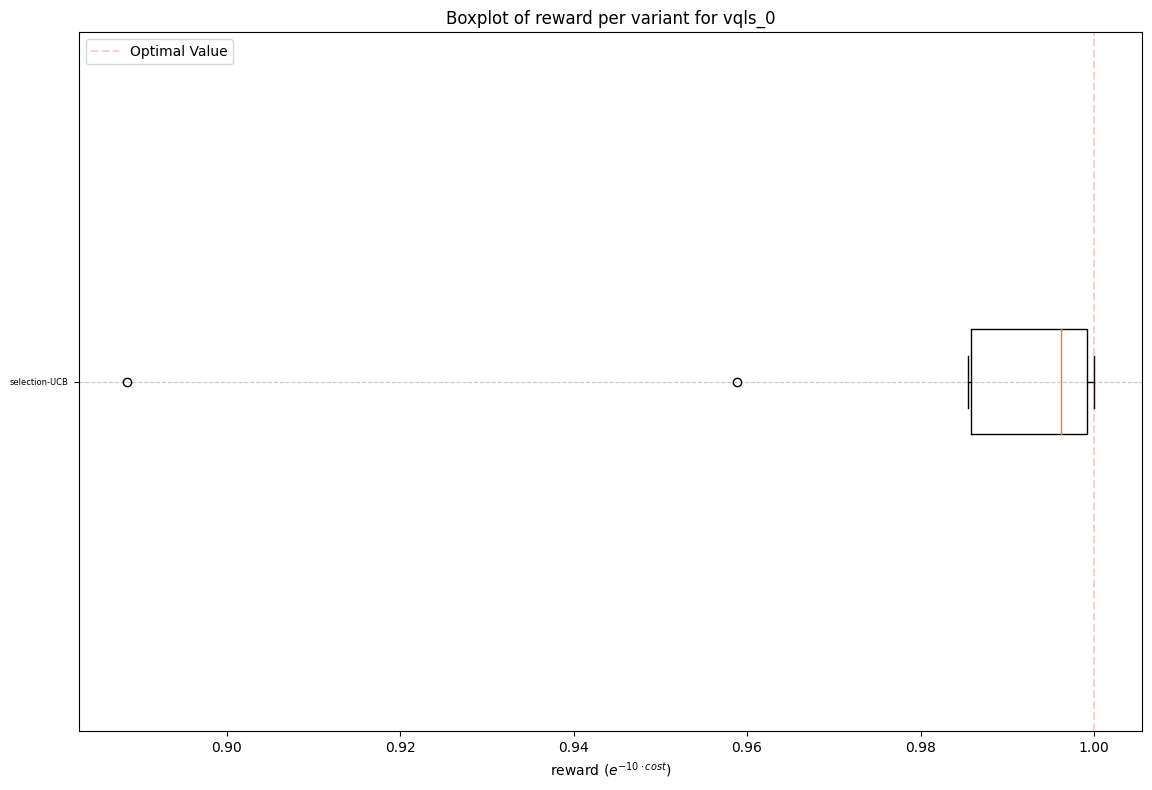

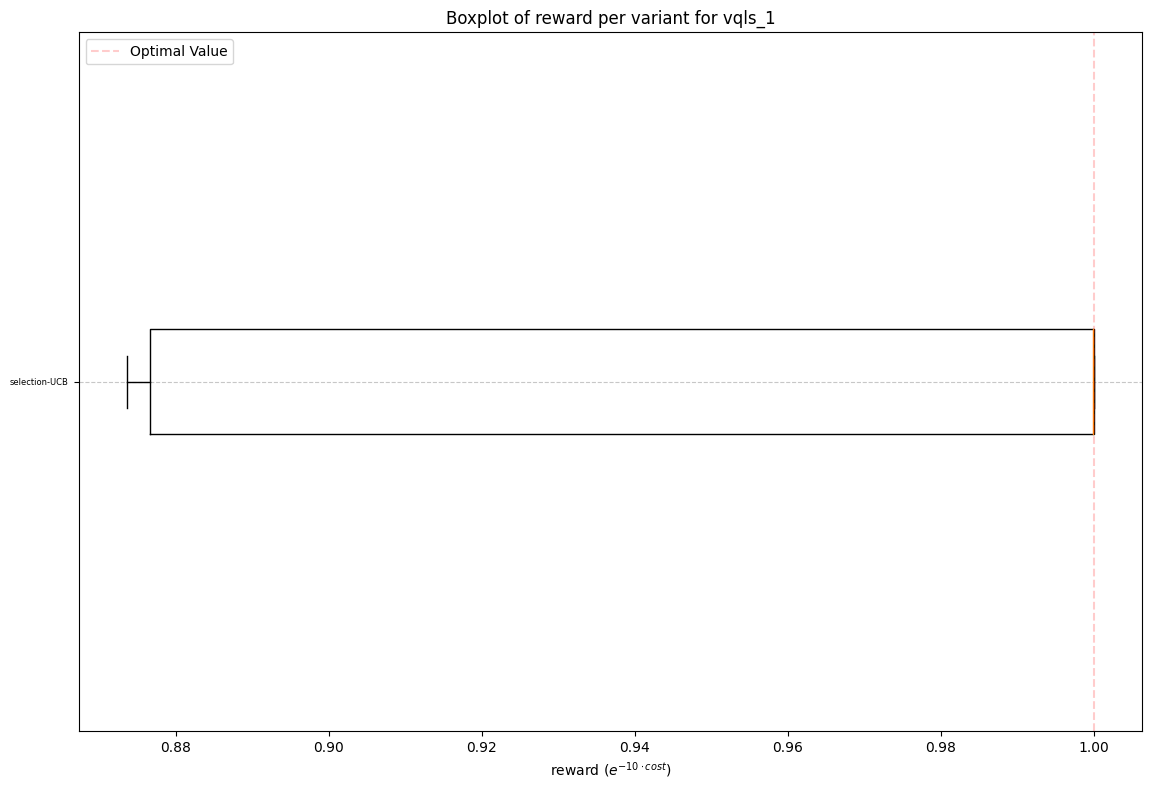

In [ ]:
rename =  {
    "standard": "Standard",
    "standard_nc": "Standard without commiting",
    "standard_nc_prob": "Baseline",  # TODO: Make correct baseline blue
    "terminal_nc": "Terminal Nodes without commiting",
    "terminal": "Terminal Nodes",

    "actions": "Group by Actions",
    "actions_pw": "Group by Actions with Progressive Widening",

    "gates": "Group by Gates",
    "gates_pw": "Group by Gates with Progressive Widening",

    "actions_gates": "Group by Actions and Gates",
    "actions_gates_pw": "Group by Actions and Gates with Progressive Widening",

    "actions_terminal": "Group by Actions and Terminal Nodes",
    "actions_pw_terminal": "Group by Actions and Terminal Nodes \n with Progressive Widening",

    "gates_terminal": "Group by Gates and Terminal Nodes",
    "gates_pw_terminal": "Group by Gates and Terminal Nodes with Progressive Widening",

    "actions_gates_terminal": "Group by Actions, Gates and Terminal Nodes",
    "actions_gates_pw_terminal": "Group by Actions, Gates and Terminal Nodes with Progressive Widening",

    "actions_change_gates_swap": "All Groupings",
    "actions_change_gates_pw_swap": "All Groupings with Progressive Widening",

    "actions_change_gates_swap_terminal": "All Groupings and Terminal Nodes",
    "actions_change_gates_pw_swap_terminal": "All Groupings and Terminal Nodes with Progressive Widening",
}
labels=[rename.get(label, label) for label in circuit_results[problem].keys()]
print(labels)
for problem in problems:
    
    plt.figure(figsize=(12, 8))
    plt.boxplot(circuit_results[problem].values(), labels = labels, vert=False)
    plt.axvline(x=optimal_value[problem], color='red', linestyle='--', label='Optimal Value', alpha=0.2)
    if problem in ['h2', 'h2o', 'lih']:
        plt.xlabel("reward (Ha)")
    else:
        plt.xlabel(r"reward ($e^{-10 \cdot cost}$)")
    plt.title(f"Boxplot of reward per variant for {problem}")
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add horizontal grid lines
    plt.legend()
    plt.yticks(fontsize=6)
    plt.show()

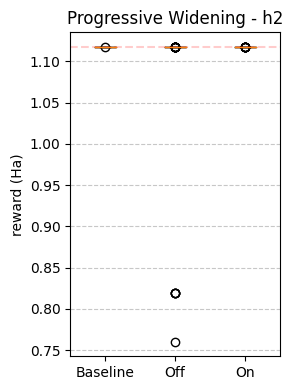

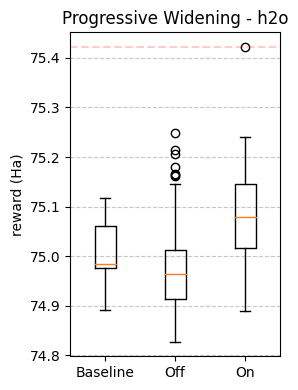

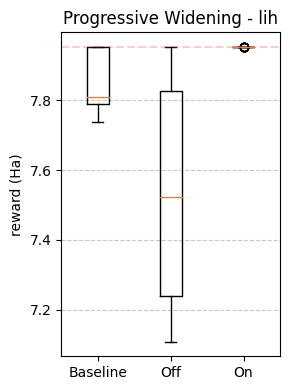

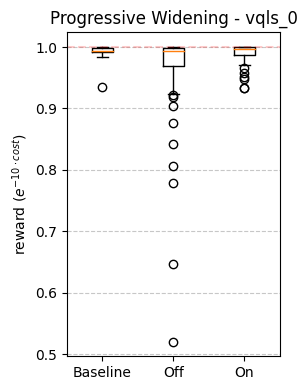

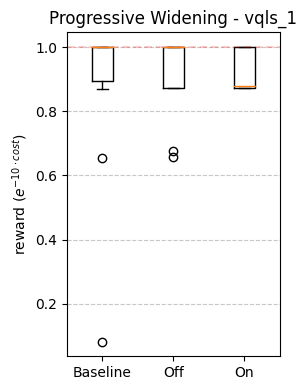

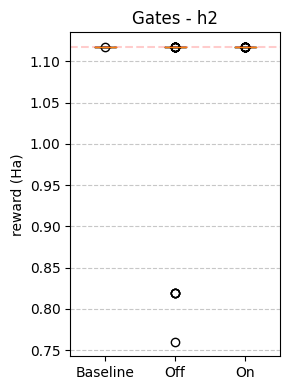

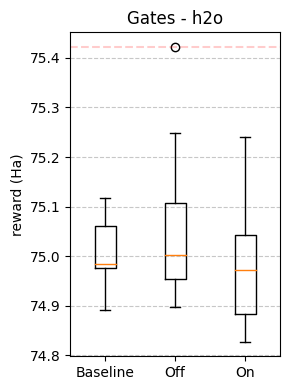

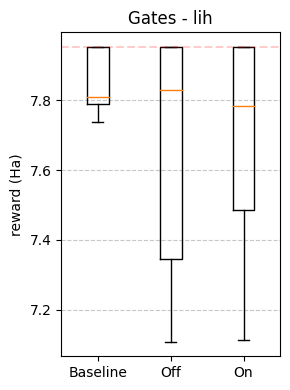

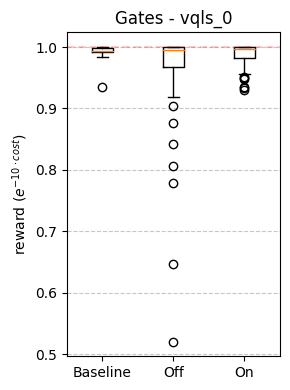

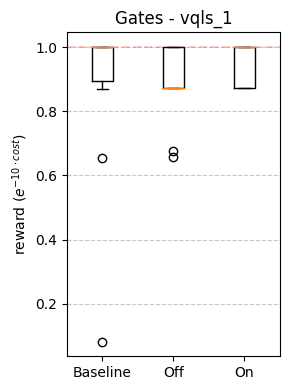

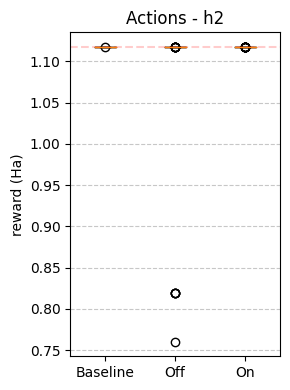

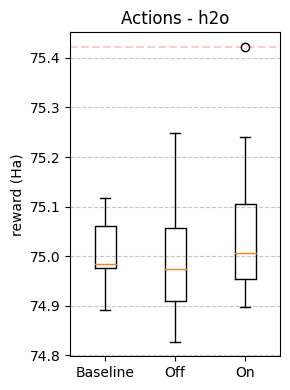

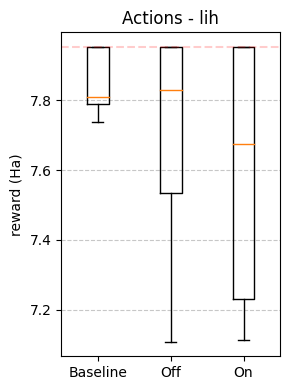

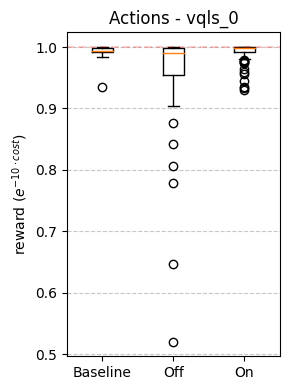

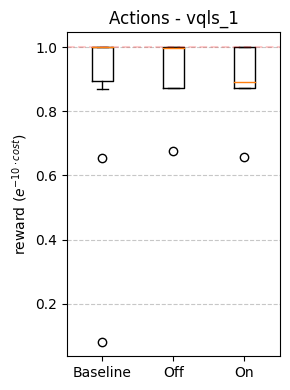

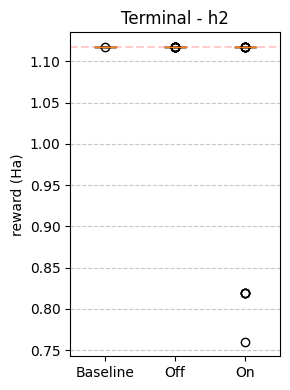

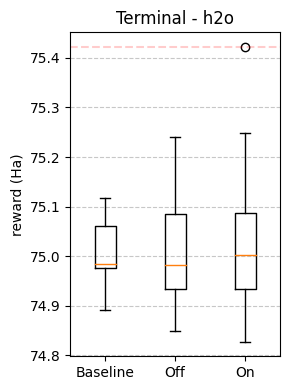

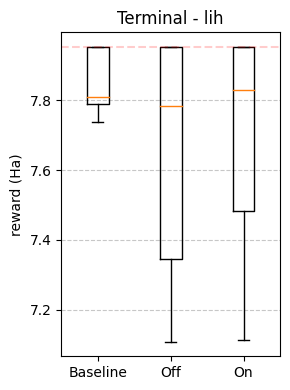

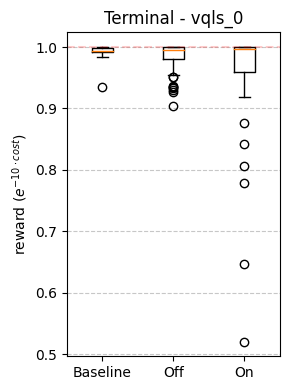

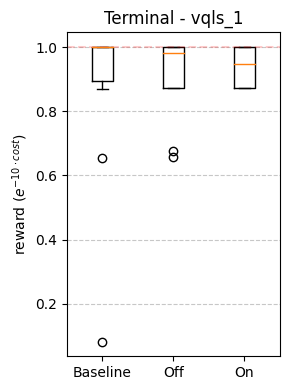

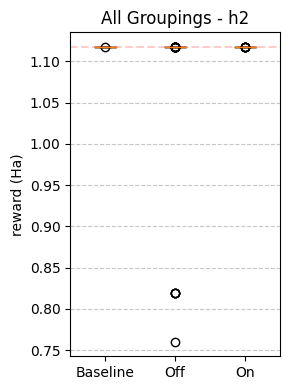

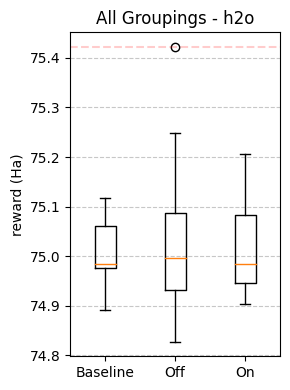

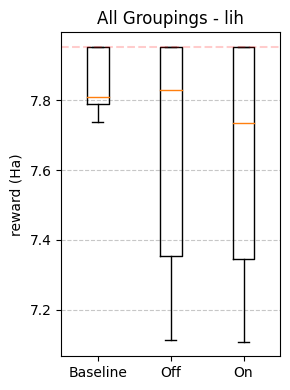

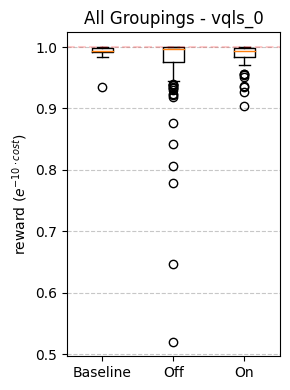

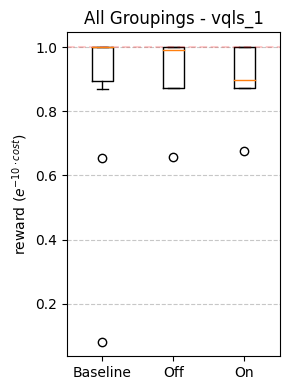

In [ ]:
to_sort = ["pw", "gates", "actions", "terminal", "change"]
names = ["Progressive Widening", "Gates", "Actions", "Terminal", "All Groupings"]

for name, sort_by in zip(names, to_sort):
    for problem in problems:
        in_group = []
        standard = []
        out_group = []
        for variant in circuit_results[problem].keys():
            if sort_by != "change" and "change" in variant:
                out_group = out_group + circuit_results[problem][variant]
            elif sort_by in variant:
                in_group = in_group + circuit_results[problem][variant]
            elif "standard_nc_prob" == variant:
                standard = standard + circuit_results[problem][variant]
            elif "standard" not in variant:
                out_group = out_group + circuit_results[problem][variant]
        
        plt.figure(figsize=(3, 4))
        plt.boxplot([standard, out_group, in_group], labels=['Baseline', 'Off', 'On'])
        plt.title(f"{name} - {problem}")
        plt.axhline(y=optimal_value[problem], color='red', linestyle='--', label='Optimal Value', alpha=0.2)
        plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add horizontal grid lines
        if problem in ['h2', 'h2o', 'lih']:
            plt.ylabel("reward (Ha)")
        else:
            plt.ylabel(r"reward ($e^{-10 \cdot cost}$)")
        plt.tight_layout()
        plt.savefig(f"groupboxplots/{sort_by}_{problem}.png")
        plt.show()


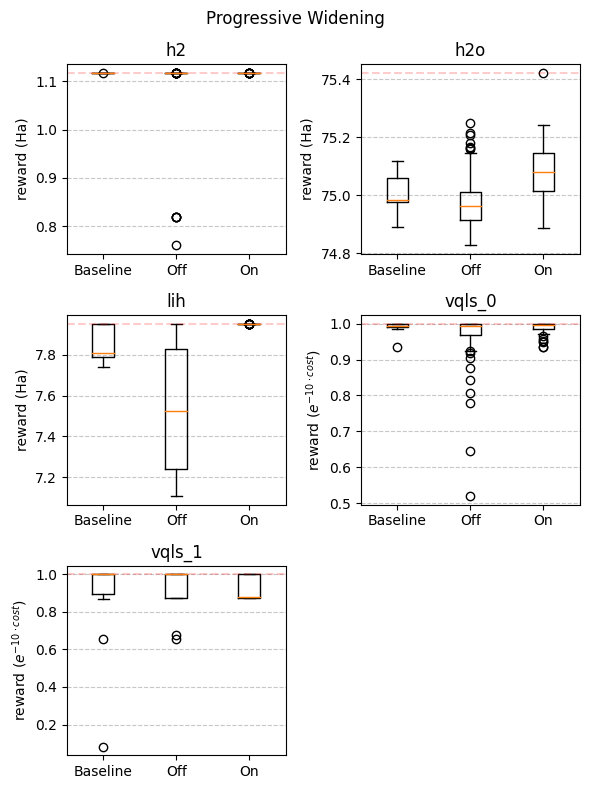

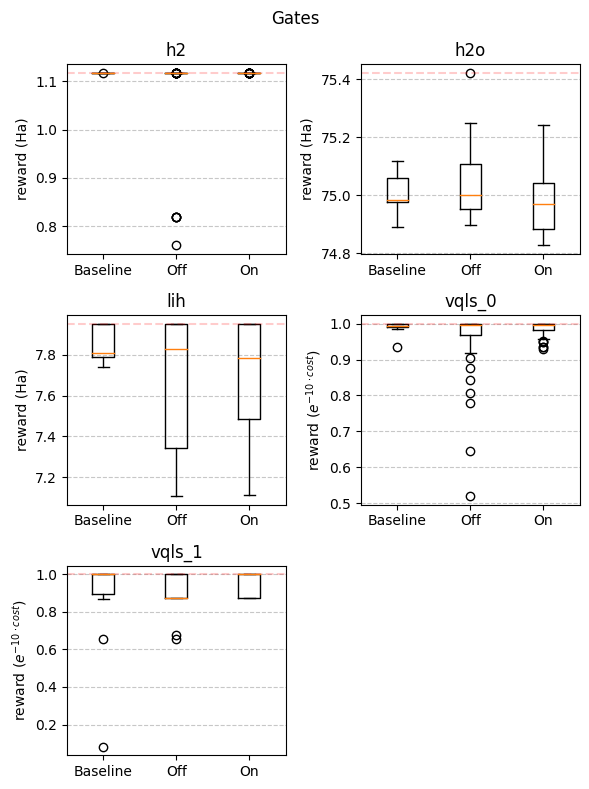

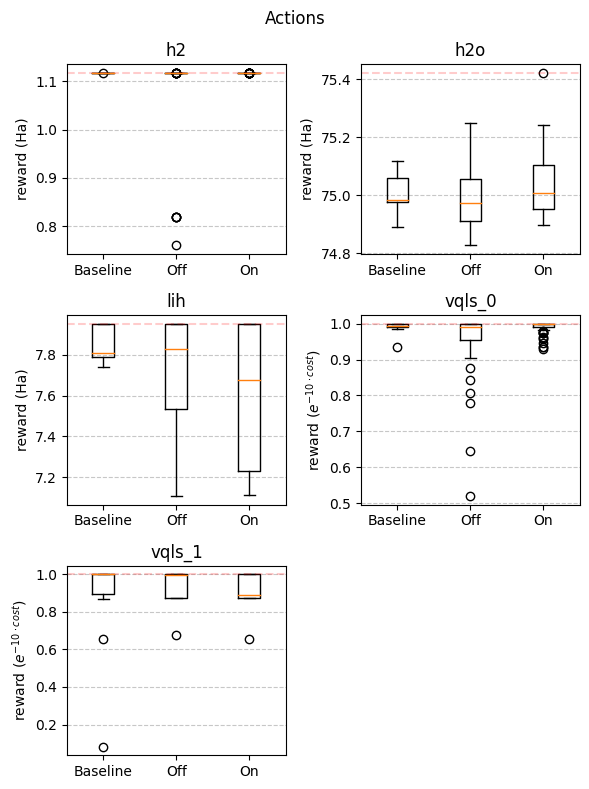

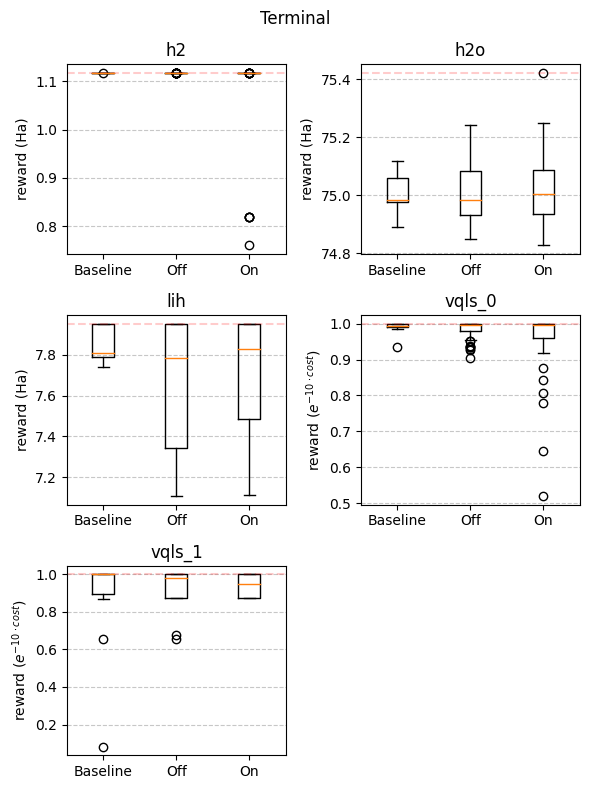

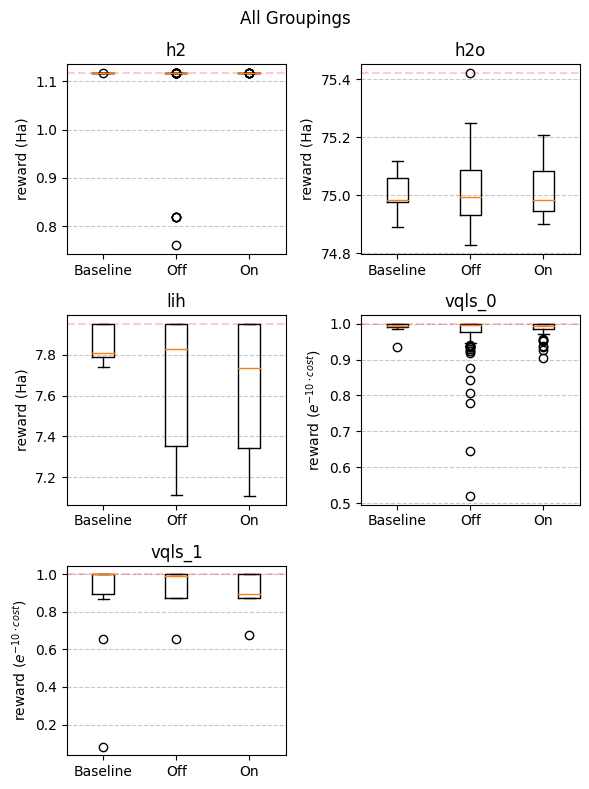

In [ ]:
to_sort = ["pw", "gates", "actions", "terminal", "change"]
names = ["Progressive Widening", "Gates", "Actions", "Terminal", "All Groupings"]

for name, sort_by in zip(names, to_sort):
    fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(6, 8))
    axes = axes.flatten()
    
    for i, problem in enumerate(problems):
        in_group = []
        standard = []
        out_group = []
        for variant in circuit_results[problem].keys():
            if sort_by != "change" and "change" in variant:
                out_group = out_group + circuit_results[problem][variant]
            elif sort_by in variant:
                in_group = in_group + circuit_results[problem][variant]
            elif "standard_nc_prob" == variant:
                standard = standard + circuit_results[problem][variant]
            elif "standard" not in variant:
                out_group = out_group + circuit_results[problem][variant]
        
        ax = axes[i]
        ax.boxplot([standard, out_group, in_group], labels=['Baseline', 'Off', 'On'])
        ax.set_title(f"{problem}")
        ax.axhline(y=optimal_value[problem], color='red', linestyle='--', label='Optimal Value', alpha=0.2)
        ax.grid(axis='y', linestyle='--', alpha=0.7)  # Add horizontal grid lines
        if problem in ['h2', 'h2o', 'lih']:
            ax.set_ylabel("reward (Ha)")
        else:
            ax.set_ylabel(r"reward ($e^{-10 \cdot cost}$)")
    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    fig.suptitle(name)  # Set the title for the figure
    plt.tight_layout()
    plt.savefig(f"groupboxplots/{sort_by}_allProblems.png")
    plt.show()


In [ ]:
vql_variant_results = {}
qc_variant_results = {}
for variant in variants:
    vql_standardized_results = []
    qc_standardized_results = []
    for problem in vql_problems:
        for run in circuit_results[problem][variant]:
            result = analysing_utils.standardize_from_stats(problem_stats[problem], run)
            vql_standardized_results.append(result)
            
    for problem in chemistry_problems:
        for run in circuit_results[problem][variant]:
            result = analysing_utils.standardize_from_stats(problem_stats[problem], run)
            qc_standardized_results.append(result)
    vql_variant_results[variant] = standardized_results
    qc_variant_results[variant] = qc_standardized_results


In [ ]:
vql_variant_results

{'standard': [0.2637068553520887,
  0.2637225986158739,
  0.26369196071725526,
  0.26371607273764364,
  0.2637169265991207,
  0.26372079337060084,
  0.26371882475919545,
  0.2637224461407204,
  0.26372249637385964,
  0.2637130982343506,
  0.7016866790748161,
  0.19249022892254836,
  0.45993618298750866,
  0.2667611953527818,
  0.3595747760024806,
  -0.6502249939209601,
  -0.6397830163561604,
  1.3013874207720182,
  0.7076877543514187,
  -0.30670823269642417,
  0.9340463712980855,
  0.9340463487046389,
  0.9340463687877922,
  0.9340463712980885,
  0.9340463712980798,
  0.9340463712980827,
  0.9340463712980827,
  0.9340463712980855,
  0.9340463712980827,
  0.9340463712980855,
  0.43876974857299417,
  -0.05333562338705467,
  -0.18377269871060906,
  0.4097846384788297,
  0.3957881274949766,
  0.3112761689776436,
  0.4386712973403411,
  0.4377807143520107,
  0.4374801034228526,
  0.4385167449160877,
  0.7425552023866884,
  0.7367578557271972,
  -0.6527114610291402,
  -0.6527114610291218,
  

<>:12: SyntaxWarning: "is not" with a literal. Did you mean "!="?
<>:12: SyntaxWarning: "is not" with a literal. Did you mean "!="?
C:\Users\mathi\AppData\Local\Temp\ipykernel_23520\449203999.py:12: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  if sort_by is not "change" and "change" in variant:


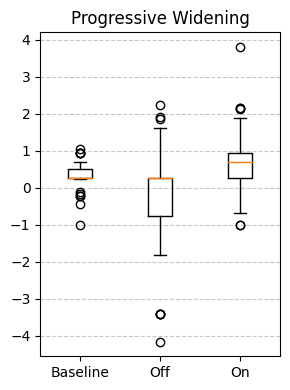

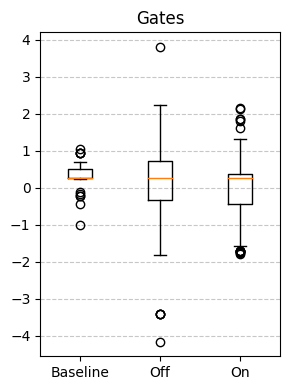

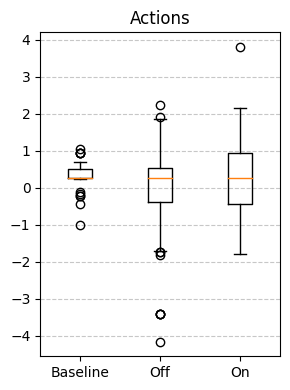

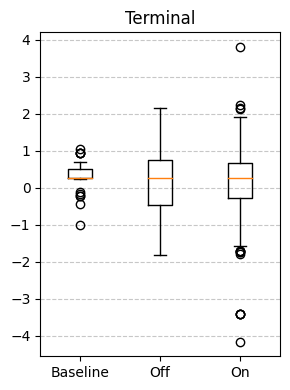

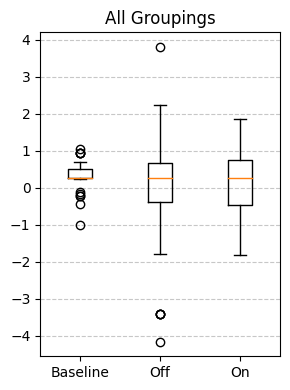

In [ ]:
to_sort = ["pw","gates","actions","terminal","change"]
names = ["Progressive Widening", "Gates", "Actions", "Terminal", "All Groupings"]
in_group = []
standard = []
out_group = []
for name, sort_by in zip(names, to_sort):

    in_group = []
    standard = []
    out_group = []
    for variant in qc_variant_results.keys():
        if sort_by is not "change" and "change" in variant:
            out_group = out_group + qc_variant_results[variant]
        elif sort_by in variant:
            in_group = in_group + qc_variant_results[variant]
        elif "standard_nc_prob" == variant:
            standard = standard + qc_variant_results[variant]
        elif "standard" not in variant:
            out_group = out_group + qc_variant_results[variant]
    plt.figure(figsize=(3, 4))
    plt.boxplot([ standard, out_group, in_group], labels=[ 'Baseline', f'Off',f"On"])
    plt.title(f"{name}")
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add horizontal grid lines
    plt.show()
        

                
            

In [ ]:
table_df
gates = analysing_utils.load_circuit_gates()


In [ ]:
gates['vqls_1']

{'actions': {'h': 3, 'r': 2, 'rx': 1, 'ry': 0, 'rz': 1, 'cx': 0},
 'actions_change_gates_pw_swap': {'h': 4,
  'r': 2,
  'rx': 1,
  'ry': 0,
  'rz': 1,
  'cx': 1},
 'actions_change_gates_pw_swap_terminal': {'h': 4,
  'r': 2,
  'rx': 0,
  'ry': 1,
  'rz': 1,
  'cx': 1},
 'actions_change_gates_swap': {'h': 3,
  'r': 2,
  'rx': 1,
  'ry': 0,
  'rz': 1,
  'cx': 0},
 'actions_change_gates_swap_terminal': {'h': 4,
  'r': 2,
  'rx': 1,
  'ry': 0,
  'rz': 1,
  'cx': 0},
 'actions_gates': {'h': 4, 'r': 3, 'rx': 1, 'ry': 1, 'rz': 1, 'cx': 0},
 'actions_gates_pw': {'h': 4, 'r': 3, 'rx': 1, 'ry': 1, 'rz': 1, 'cx': 0},
 'actions_gates_pw_terminal': {'h': 4,
  'r': 2,
  'rx': 1,
  'ry': 0,
  'rz': 1,
  'cx': 0},
 'actions_gates_terminal': {'h': 4,
  'r': 3,
  'rx': 1,
  'ry': 0,
  'rz': 2,
  'cx': 0},
 'actions_pw': {'h': 3, 'r': 2, 'rx': 1, 'ry': 0, 'rz': 1, 'cx': 0},
 'actions_pw_terminal': {'h': 4, 'r': 3, 'rx': 1, 'ry': 1, 'rz': 1, 'cx': 0},
 'actions_terminal': {'h': 4, 'r': 2, 'rx': 0, 'ry': 1,